# Lab 1
## Dynamic model of a multi-link manipulator

## Steps

### 0. Import the necessary libraries

In [253]:
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt

### 1. Import robot model (UR5)

In [254]:
robot = rtb.models.DH.UR5()
print(robot)

DHRobot: UR5 (by Universal Robotics), 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │ 0.08946 │       0 │  90.0° │
│  q2 │       0 │  -0.425 │   0.0° │
│  q3 │       0 │ -0.3922 │   0.0° │
│  q4 │  0.1091 │       0 │  90.0° │
│  q5 │ 0.09465 │       0 │ -90.0° │
│  q6 │  0.0823 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬───────┬─────┬─────┬─────┬──────┬─────┐
│ name │ q0    │ q1  │ q2  │ q3  │ q4   │ q5  │
├──────┼───────┼─────┼─────┼─────┼──────┼─────┤
│   qr │  180° │  0° │  0° │  0° │  90° │  0° │
│   qz │  0°   │  0° │  0° │  0° │  0°  │  0° │
└──────┴───────┴─────┴─────┴─────┴──────┴─────┘



### 2. Fill in the parameters of the robot model (in the example, filled in for the Puma560 robot)

0. Using dyn() you can view the dynamic parameters of each link

In [255]:
print(robot.links[0].dyn())  # initial dynamic parameters of the first link

m     =       3.7 
r     =         0   -0.026   0.0019 
        |        0        0        0 | 
I     = |        0        0        0 | 
        |        0        0        0 | 
Jm    =         0 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         1 
qlim  =         0 to        0


1. Let's define the mass of the links

In [256]:
robot.links[0].m = 3.7
robot.links[1].m = 7.1
robot.links[2].m = 2.27
robot.links[3].m = 1.21
robot.links[4].m = 1.21
robot.links[5].m = 0.1879

2. Let's define the center of mass of each link

In [257]:
robot.links[0].r = [0, -0.02561, 0.00193]
robot.links[1].r = [0.2125, 0, 0.11336]
robot.links[2].r =[0.2125, 0, 0.11336]
robot.links[3].r = [0, -0.0161, 0.0514]
robot.links[4].r = [0, -0.0161, 0.0514]
robot.links[5].r = [0, -0.0011, 0.0116] 

3. Let's define the inertia tensor of each link. Filling: [Lxx, Lyy, Lzz, Lxy, Lyz, Lxz]

In [258]:
robot.links[0].I =  [0.010267, 0.010267, 0.00666, 0, 0, 0]
robot.links[1].I = [0.22689, 0.22689, 0.015107, 0, 0, 0]
robot.links[2].I = [0.049443, 0.049443, 0.004095, 0, 0, 0]
robot.links[3].I = [0.001367, 0.001367, 0.001169, 0, 0, 0]
robot.links[4].I = [0.001367, 0.001367, 0.001169, 0, 0, 0]
robot.links[5].I = [0.000365, 0.000365, 0.000199, 0, 0, 0] 

4. Let's set the moment of inertia of the drive

In [259]:
robot.links[0].Jm = 0.000033
robot.links[1].Jm = 0.000033
robot.links[2].Jm = 0.000033
robot.links[3].Jm = 0.000033
robot.links[4].Jm = 0.000033
robot.links[5].Jm = 0.000033

5. Let's define the coefficient of viscous friction of the drive

In [260]:
robot.links[0].B = 0.0015
robot.links[1].B = 0.000817
robot.links[2].B = 0.00138
robot.links[3].B = 0.0000712
robot.links[4].B = 0.0000826
robot.links[5].B = 0.0000367

6. Let's define the coefficient of Coulomb friction of the drive

In [261]:
robot.links[0].Tc = [0.395, -0.435]
robot.links[1].Tc = [0.126, -0.071]
robot.links[2].Tc = [0.132, -0.105]
robot.links[3].Tc = [0.0112, -0.0169]
robot.links[4].Tc = [0.00926, -0.0145]
robot.links[5].Tc = [0.00396, -0.0105]

7. Let's set the gear ratio for each link

In [262]:
robot.links[0].G = 101.0
robot.links[1].G = 101.0
robot.links[2].G = 101.0
robot.links[3].G = 101.0
robot.links[4].G = 101.0
robot.links[5].G = 101.0

8. Let's set restrictions on the generalized coordinates for each link

In [263]:
robot.links[0].qlim = [-2*pi, 2*pi]
robot.links[1].qlim = [-2*pi, 2*pi]
robot.links[2].qlim = [-2*pi, 2*pi]
robot.links[3].qlim = [-2*pi, 2*pi]
robot.links[4].qlim = [-2*pi, 2*pi]
robot.links[5].qlim = [-2*pi, 2*pi]

### 3. Set the initial and final positions of the robot and plot them

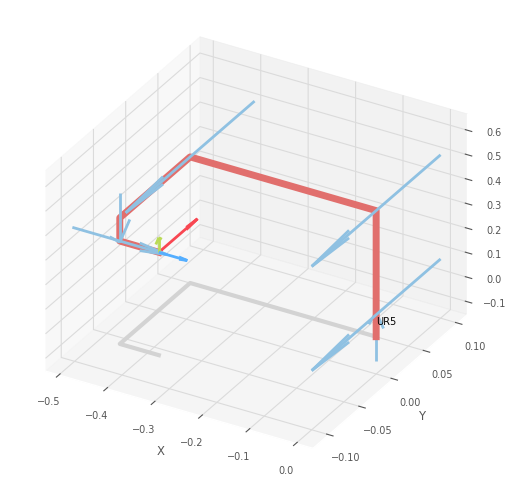

<Figure size 640x480 with 0 Axes>

In [264]:
q_start = [0, -pi/2, pi/2, 0,  -pi/2, 0]
robot.plot(q_start)
plt.show()

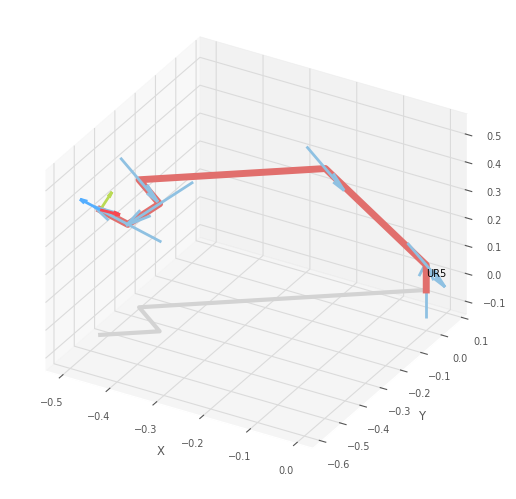

<Figure size 640x480 with 0 Axes>

In [265]:
q_end = [pi/4, -pi/3, pi/3, -pi/4, pi/2, pi/6]
robot.plot(q_end)
plt.show()

### 4. Plan the trajectory with prebuilt functions


Trajectory shape:
  Positions: (200, 6)
  Velocities: (200, 6)
  Accelerations: (200, 6)


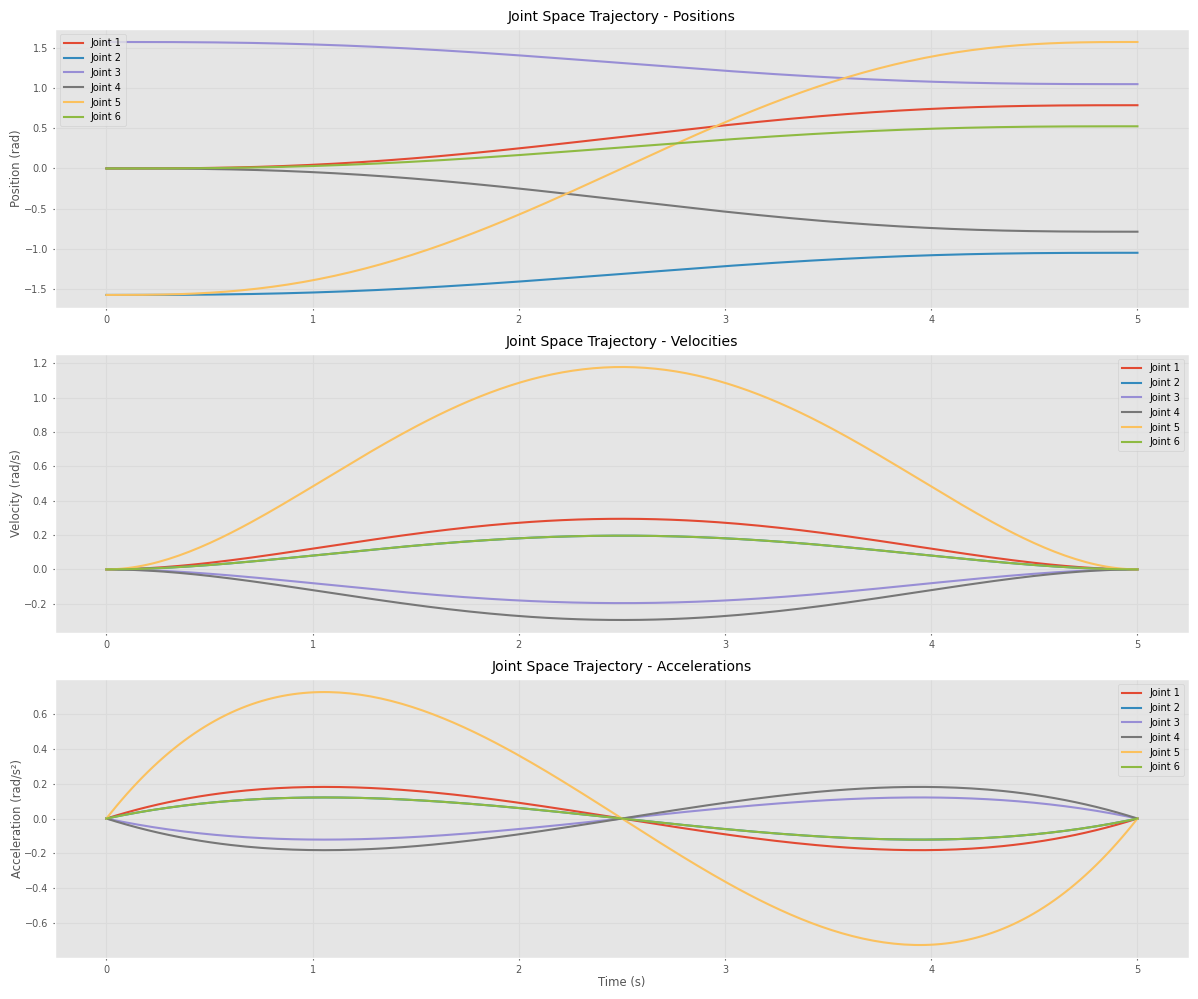

In [266]:
# Trajectory parameters
N = 200  # Number of points
t_start = 0
t_stop = 5  # 5 seconds trajectory duration
t = np.linspace(t_start, t_stop, N)
dt = t[1] - t[0]

# Generate joint-space trajectory using trapezoidal velocity profile (jtraj)
traj = rtb.jtraj(q_start, q_end, t)

# Extract position, velocity, and acceleration
q_traj = traj.q      # Joint positions (N x 6)
qd_traj = traj.qd    # Joint velocities (N x 6)
qdd_traj = traj.qdd  # Joint accelerations (N x 6)

print(f"\nTrajectory shape:")
print(f"  Positions: {q_traj.shape}")
print(f"  Velocities: {qd_traj.shape}")
print(f"  Accelerations: {qdd_traj.shape}")

# Plot trajectory profiles
fig2, axes = plt.subplots(3, 1, figsize=(12, 10))

# Joint positions
for j in range(6):
    axes[0].plot(t, q_traj[:, j], label=f'Joint {j+1}', linewidth=1.5)
axes[0].set_ylabel('Position (rad)')
axes[0].set_title('Joint Space Trajectory - Positions')
axes[0].legend()
axes[0].grid(True)

# Joint velocities
for j in range(6):
    axes[1].plot(t, qd_traj[:, j], label=f'Joint {j+1}', linewidth=1.5)
axes[1].set_ylabel('Velocity (rad/s)')
axes[1].set_title('Joint Space Trajectory - Velocities')
axes[1].legend()
axes[1].grid(True)

# Joint accelerations
for j in range(6):
    axes[2].plot(t, qdd_traj[:, j], label=f'Joint {j+1}', linewidth=1.5)
axes[2].set_ylabel('Acceleration (rad/s²)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('Joint Space Trajectory - Accelerations')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

### 5. Solve the inverse dynamics

In [267]:
# ============================================================================
# Step 5: Solve the inverse dynamics problem using Newton-Euler method
# ============================================================================

print("\n" + "=" * 60)
print("Inverse Dynamics Analysis using Newton-Euler Method")
print("=" * 60)

# Scenario 1: Non-zero velocities and accelerations (q̇ ≠ 0, q̈ ≠ 0)
print("\nScenario 1: Full dynamics (q̇ ≠ 0, q̈ ≠ 0)")
print("-" * 50)
tau_full = robot.rne(q_traj, qd_traj, qdd_traj).T
print(f"  Computed joint torques for {N} trajectory points")
print(f"  Torque matrix shape: {tau_full.shape}")

# Scenario 2: Non-zero velocities, negligible accelerations (quasi-statics)
print("\nScenario 2: Quasi-static motion (q̇ ≠ 0, q̈ ≈ 0)")
print("-" * 50)
tau_quasi = robot.rne(q_traj, qd_traj, np.zeros_like(qdd_traj)).T
print(f"  Computed joint torques neglecting acceleration effects")

# Scenario 3: Zero velocities and accelerations (maintaining position)
print("\nScenario 3: Static position maintenance (q̇ = 0, q̈ = 0)")
print("-" * 50)
tau_static = robot.rne(q_traj, np.zeros_like(qd_traj), np.zeros_like(qdd_traj)).T
print(f"  Computed gravity compensation torques")

# Calculate torque statistics for each scenario
print("\nTorque Statistics (Nm):")
print("-" * 70)
print(f"{'Joint':<8} {'Full Dyn Max':<15} {'Quasi Max':<15} {'Static Max':<15}")
print("-" * 70)
for j in range(6):
    print(f"Joint {j+1}:   {np.max(np.abs(tau_full[j])):<15.3f} {np.max(np.abs(tau_quasi[j])):<15.3f} {np.max(np.abs(tau_static[j])):<15.3f}")
print("-" * 70)


Inverse Dynamics Analysis using Newton-Euler Method

Scenario 1: Full dynamics (q̇ ≠ 0, q̈ ≠ 0)
--------------------------------------------------
  Computed joint torques for 200 trajectory points
  Torque matrix shape: (6, 200)

Scenario 2: Quasi-static motion (q̇ ≠ 0, q̈ ≈ 0)
--------------------------------------------------
  Computed joint torques neglecting acceleration effects

Scenario 3: Static position maintenance (q̇ = 0, q̈ = 0)
--------------------------------------------------
  Computed gravity compensation torques

Torque Statistics (Nm):
----------------------------------------------------------------------
Joint    Full Dyn Max    Quasi Max       Static Max     
----------------------------------------------------------------------
Joint 1:   44.512          44.504          0.000          
Joint 2:   20.937          20.920          33.646         
Joint 3:   28.586          28.611          16.077         
Joint 4:   3.743           3.780           2.039          
Jo

In [268]:
# ============================================================================
# Step 5: Solve the inverse dynamics problem using Newton-Euler method
# ============================================================================

print("\n" + "=" * 60)
print("Inverse Dynamics Analysis using Newton-Euler Method")
print("=" * 60)

# Scenario 1: Non-zero velocities and accelerations (q̇ ≠ 0, q̈ ≠ 0)
print("\nScenario 1: Full dynamics (q̇ ≠ 0, q̈ ≠ 0)")
print("-" * 50)
tau_full = robot.rne(q_traj, qd_traj, qdd_traj).T
print(f"  Computed joint torques for {N} trajectory points")
print(f"  Torque matrix shape: {tau_full.shape}")

# Scenario 2: Non-zero velocities, negligible accelerations (quasi-statics)
print("\nScenario 2: Quasi-static motion (q̇ ≠ 0, q̈ ≈ 0)")
print("-" * 50)
tau_quasi = robot.rne(q_traj, qd_traj, np.zeros_like(qdd_traj)).T
print(f"  Computed joint torques neglecting acceleration effects")

# Scenario 3: Zero velocities and accelerations (maintaining position)
print("\nScenario 3: Static position maintenance (q̇ = 0, q̈ = 0)")
print("-" * 50)
tau_static = robot.rne(q_traj, np.zeros_like(qd_traj), np.zeros_like(qdd_traj)).T
print(f"  Computed gravity compensation torques")

# Calculate torque statistics for each scenario
print("\nTorque Statistics (Nm):")
print("-" * 70)
print(f"{'Joint':<8} {'Full Dyn Max':<15} {'Quasi Max':<15} {'Static Max':<15}")
print("-" * 70)
for j in range(6):
    print(f"Joint {j+1}:   {np.max(np.abs(tau_full[j])):<15.3f} {np.max(np.abs(tau_quasi[j])):<15.3f} {np.max(np.abs(tau_static[j])):<15.3f}")
print("-" * 70)


Inverse Dynamics Analysis using Newton-Euler Method

Scenario 1: Full dynamics (q̇ ≠ 0, q̈ ≠ 0)
--------------------------------------------------
  Computed joint torques for 200 trajectory points
  Torque matrix shape: (6, 200)

Scenario 2: Quasi-static motion (q̇ ≠ 0, q̈ ≈ 0)
--------------------------------------------------
  Computed joint torques neglecting acceleration effects

Scenario 3: Static position maintenance (q̇ = 0, q̈ = 0)
--------------------------------------------------
  Computed gravity compensation torques

Torque Statistics (Nm):
----------------------------------------------------------------------
Joint    Full Dyn Max    Quasi Max       Static Max     
----------------------------------------------------------------------
Joint 1:   44.512          44.504          0.000          
Joint 2:   20.937          20.920          33.646         
Joint 3:   28.586          28.611          16.077         
Joint 4:   3.743           3.780           2.039          
Jo

In [269]:
# ============================================================================
# Step 6: Determine numerical values of M(q), C(q, q̇), G(q) matrices
# ============================================================================

print("\n" + "=" * 60)
print("Dynamic Model Components Analysis")
print("=" * 60)

# For Scenario 1 (full dynamics)
print("\nScenario 1: Full dynamics (q̇ ≠ 0, q̈ ≠ 0)")
print("-" * 50)

# Mass matrix M(q)
M_matrix = robot.inertia(q_traj)  # Returns N x 6 x 6 matrix
print(f"M(q) - Mass matrix: {M_matrix.shape}")

# Coriolis and centrifugal matrix C(q, q̇)
C_matrix = robot.coriolis(q_traj, qd_traj)  # Returns N x 6 x 6 matrix
print(f"C(q, q̇) - Coriolis matrix: {C_matrix.shape}")

# Gravity vector G(q)
G_vector = robot.gravload(q_traj)  # Returns N x 6 matrix
print(f"G(q) - Gravity vector: {G_vector.shape}")

# For Scenario 2 (quasi-statics)
print("\nScenario 2: Quasi-statics (q̇ ≠ 0, q̈ = 0)")
print("-" * 50)
M_quasi = robot.inertia(q_traj)
C_quasi = robot.coriolis(q_traj, qd_traj)
G_quasi = robot.gravload(q_traj)

# For Scenario 3 (static)
print("\nScenario 3: Static (q̇ = 0, q̈ = 0)")
print("-" * 50)
M_static = robot.inertia(q_traj)
C_static = robot.coriolis(q_traj, np.zeros_like(qd_traj))
G_static = robot.gravload(q_traj)

# Display sample values at midpoint
mid_idx = N // 2
print("\nSample values at t = {:.2f} s:".format(t[mid_idx]))
print("-" * 50)
print(f"\nMass Matrix M(q) at midpoint:")
print(f"  Shape: {M_matrix[mid_idx].shape}")
print(f"  Diagonal elements: {np.diag(M_matrix[mid_idx])}")
print(f"\nCoriolis Matrix C(q, q̇) at midpoint:")
print(f"  Norm: {np.linalg.norm(C_matrix[mid_idx]):.4f}")
print(f"\nGravity Vector G(q) at midpoint:")
for j in range(6):
    print(f"  G[{j+1}] = {G_vector[mid_idx, j]:.3f} Nm")


Dynamic Model Components Analysis

Scenario 1: Full dynamics (q̇ ≠ 0, q̈ ≠ 0)
--------------------------------------------------
M(q) - Mass matrix: (200, 6, 6)
C(q, q̇) - Coriolis matrix: (200, 6, 6)
G(q) - Gravity vector: (200, 6)

Scenario 2: Quasi-statics (q̇ ≠ 0, q̈ = 0)
--------------------------------------------------

Scenario 3: Static (q̇ = 0, q̈ = 0)
--------------------------------------------------

Sample values at t = 2.51 s:
--------------------------------------------------

Mass Matrix M(q) at midpoint:
  Shape: (6, 6)
  Diagonal elements: [1.75760151 2.29484332 0.90351065 0.35912842 0.34321854 0.33683223]

Coriolis Matrix C(q, q̇) at midpoint:
  Norm: 0.5531

Gravity Vector G(q) at midpoint:
  G[1] = -0.000 Nm
  G[2] = -24.037 Nm
  G[3] = -14.859 Nm
  G[4] = -0.821 Nm
  G[5] = 0.302 Nm
  G[6] = -0.000 Nm


### 6. Obtain the components of the dynamic equation

In [270]:
# M = robot.inertia(tr.q)
# C = robot.coriolis(tr.q, tr.qd)
# G = robot.gravload(tr.q)

# M0 = robot.inertia(tr.q)
# C0 = robot.coriolis(tr.q, np.zeros([N,6]))
# G0 = robot.gravload(tr.q)

### 7. Plot the graphs


Generating Torque Plots


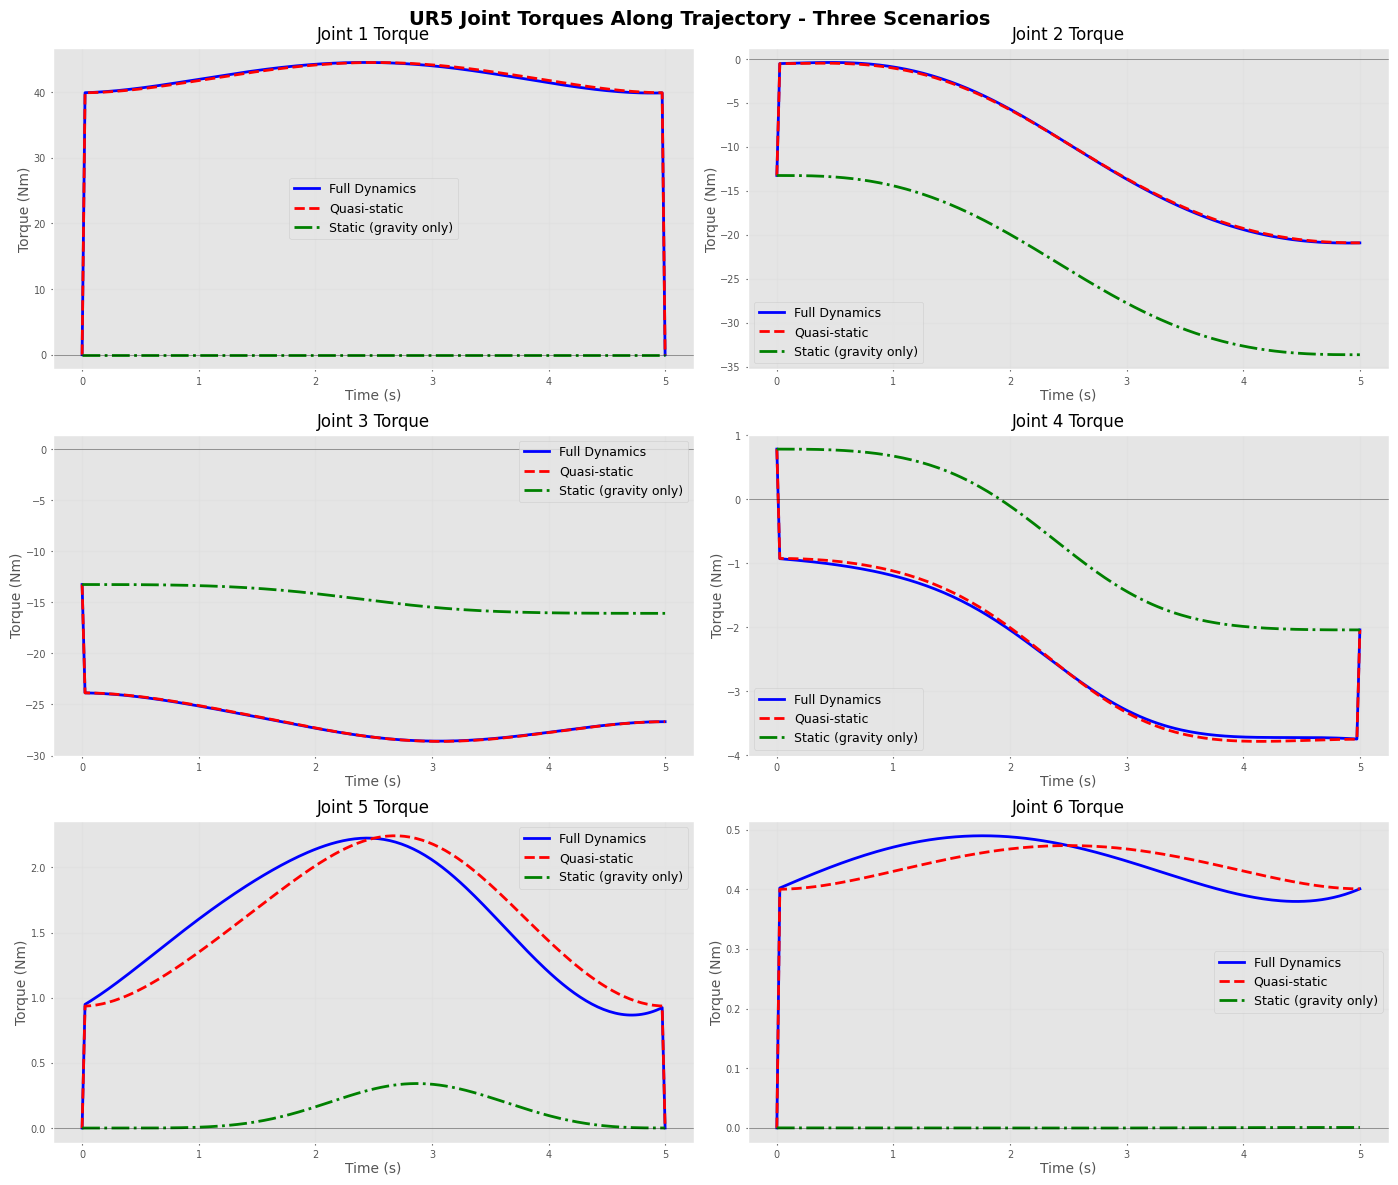

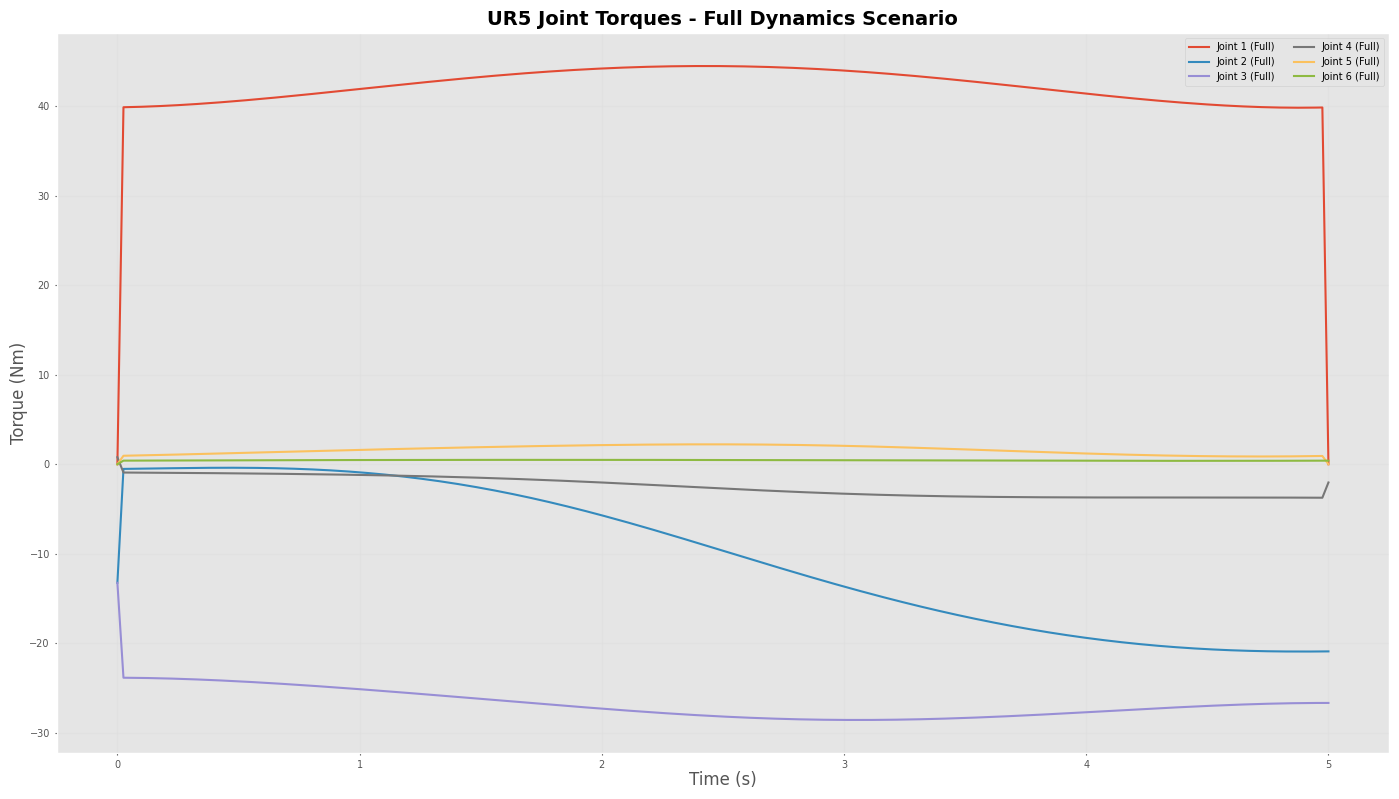

In [ ]:
plt.figure(figsize=(10,5), dpi=300)  # Задаем размеры холста и плотность точек (четкость графика)
for g in range(6):
    plt.subplot(2,3,g+1)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.2, hspace=0.25)  # Задаем интервалы между графиками, чтоб не перекрывали друг друга
    plt.plot(time, tau[g], linewidth=2, label=r"$\tau$")  # Строим график
    plt.plot(time, tau0[g], linewidth=2, label=r"$\tau_{0}$")  # Строим график
    plt.title(r"Link moment {}".format(g+1), fontsize=10)  # Название графика
    plt.ylabel(r"$N \cdot m$", fontsize=9)  # Подпись оси Y
    plt.xlabel(r"$sec$", fontsize=9)  # Подпись оси X
    plt.grid(True)  # Добавить сетку
    plt.legend()  # Отобразить легенду (покажет то, что написано в 'label')
    ax = plt.gca()  # gca = get current axis - чтобы редактировать конкретную фигуру
    ax.set_facecolor((1,1,1))  # Цвет фона на графике
    ax.set_xlim([t_start-0.1,t_stop+0.1])  # Пределы по оси X
plt.show()